<a href="https://colab.research.google.com/github/LeonimerMelo/GANs/blob/GAN-Pytorch/StyleGAN2_ADA_pretreinada_para_gerar_imagens_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teste com Style-GAN2 - ADA

Este notebook gera imagens sintéticas usando o **StyleGAN2-ADA** da NVIDIA com o modelo FFHQ (rostos humanos).

**Pré-requisito:** Este notebook deve ser executado *dentro da pasta* do repositório clonado. Caso contrário, o compilador recalmará de não conseguir encontrar algumas bilbiotecas.

O comando abaxio está configurado para rodar em um terminal Linux, mas baixar o repositório e colocar este notebook dentro manualmente também deve funcionar.

> ```bash
> git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
> cd stylegan2-ada-pytorch
> cp Notebook.ipynb stylegan2-ada-pytorch/
> ```

Depois reabra este arquivo de dentro da pasta e tudo deve funcionar como esperado.

## 1. Instalação de Dependências

In [ ]:
# Roda o pip para baixar e instalar as dependências. Na minha configuração, um ambiente .venv
# funcionou bem, mas deve rodar caso seja instalado global também.
%pip install torch torchvision Pillow numpy click requests --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Imports e Verificação do Ambiente

In [ ]:
import os, sys
import numpy as np
import torch
import PIL.Image
import matplotlib.pyplot as plt
import warnings
import logging

# Verifica se está na pasta correta:
if not os.path.isdir("torch_utils"):
    raise RuntimeError(
        "Pasta 'torch_utils' não encontrada!\n"
        "Este notebook precisa estar dentro da pasta do repositório:\n"
        "  git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git\n"
        "  cd stylegan2-ada-pytorch"
    )

import dnnlib
import legacy

# Info da GPU:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU encontrada: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("CUDA não encontrado — usando CPU (mais lento)")

print(f"   PyTorch: {torch.__version__}")

GPU encontrada: NVIDIA GeForce GTX 1650
VRAM disponível: 3.9 GB
   PyTorch: 2.12.0+cu130


## 3. Configurações

Altere as variáveis abaixo para customizar a geração.

In [ ]:
# Seeds: cada número gera um rosto diferente
SEEDS = [42, 123, 777, 2024]

# Truncation psi:
#   0.3 → rostos mais "médios", próximos da média do dataset
#   0.7 → bom equilíbrio qualidade/variedade (recomendado)
#   1.0 → máxima variedade, pode gerar rostos mais incomuns
TRUNCATION_PSI = 0.7

# Modelo pré-treinado
# Outros disponíveis:
#   metfaces → rostos em estilo pintura clássica
#   afhqcat  → gatos
#   afhqdog  → cães
MODEL_URL = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"

# Pasta de saída
OUTPUT_DIR = "output_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

warnings.filterwarnings("ignore")
logging.getLogger('torch_extensions').setLevel(logging.ERROR)

print(f"Seeds: {SEEDS}")
print(f"Truncation psi: {TRUNCATION_PSI}")
print(f"Modelo: {MODEL_URL.split('/')[-1]}")

Seeds: [42, 123, 777, 2024]
Truncation psi: 0.7
Modelo: ffhq.pkl


## 4. Carregamento do Modelo

O `dnnlib` baixa e faz cache do modelo automaticamente (~200 MB na primeira execução).

In [ ]:
print("Carregando modelo (aguarde o download na 1ª execução)...")

with dnnlib.util.open_url(MODEL_URL) as f:
    G = legacy.load_network_pkl(f)["G_ema"].to(device)

G.eval()
print(f"Modelo carregado!")
print(f"Dimensão z: {G.z_dim}")
print(f"Resolução:  {G.img_resolution}x{G.img_resolution} px")

Carregando modelo (aguarde o download na 1ª execução)...
Modelo carregado!
Dimensão z: 512
Resolução:  1024x1024 px


## 5. Geração de Imagens

In [ ]:
label = torch.zeros([1, G.c_dim], device=device)
imagens = []

with torch.no_grad():
    for seed in SEEDS:
        z = torch.from_numpy(
            np.random.RandomState(seed).randn(1, G.z_dim).astype(np.float32)
        ).to(device)

        img_tensor = G(z, label, truncation_psi=TRUNCATION_PSI, noise_mode="const")
        img_np = (img_tensor.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255)
        img_pil = PIL.Image.fromarray(img_np[0].cpu().numpy().astype(np.uint8), "RGB")

        caminho = os.path.join(OUTPUT_DIR, f"seed{seed:04d}.png")
        img_pil.save(caminho)
        imagens.append((seed, img_pil))
        print(f"  seed {seed:>4} → {caminho}")

print(f"\n{len(imagens)} imagem(ns) gerada(s)!")

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
  seed   42 → output_images/seed0042.png
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting

Os erros de compilação expostos acima são devido a incompatibilidades das versões da biblioteca que estamos utilizando. Lembre-se que este repositório foi desenvolvido por volta de 2020 e muita coisa mudou desde então. O código ainda roda na GPU pra que possui CUDA.

## 6. Visualização Inline

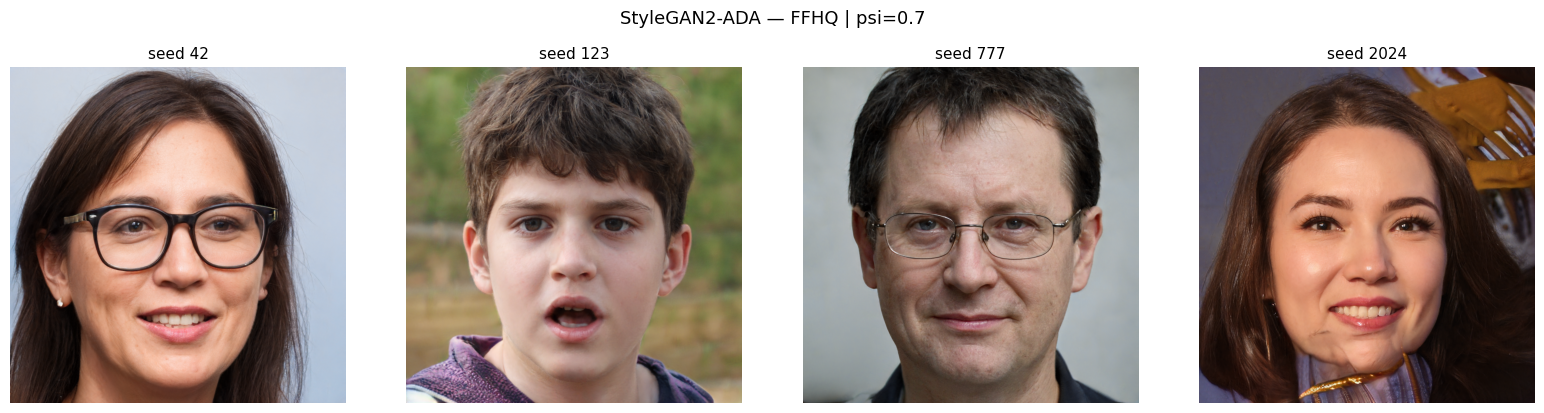

Grid salvo em: output_images/grid.png


In [ ]:
n = len(imagens)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

if n == 1:
    axes = [axes]

for ax, (seed, img) in zip(axes, imagens):
    ax.imshow(img)
    ax.set_title(f"seed {seed}", fontsize=11)
    ax.axis("off")

plt.suptitle(f"StyleGAN2-ADA — FFHQ | psi={TRUNCATION_PSI}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid.png"), bbox_inches="tight", dpi=150)
plt.show()
print(f"Grid salvo em: {OUTPUT_DIR}/grid.png")

## 7. Experimento: Efeito do Truncation Psi

Veja como o mesmo rosto muda com diferentes valores de `psi`.

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

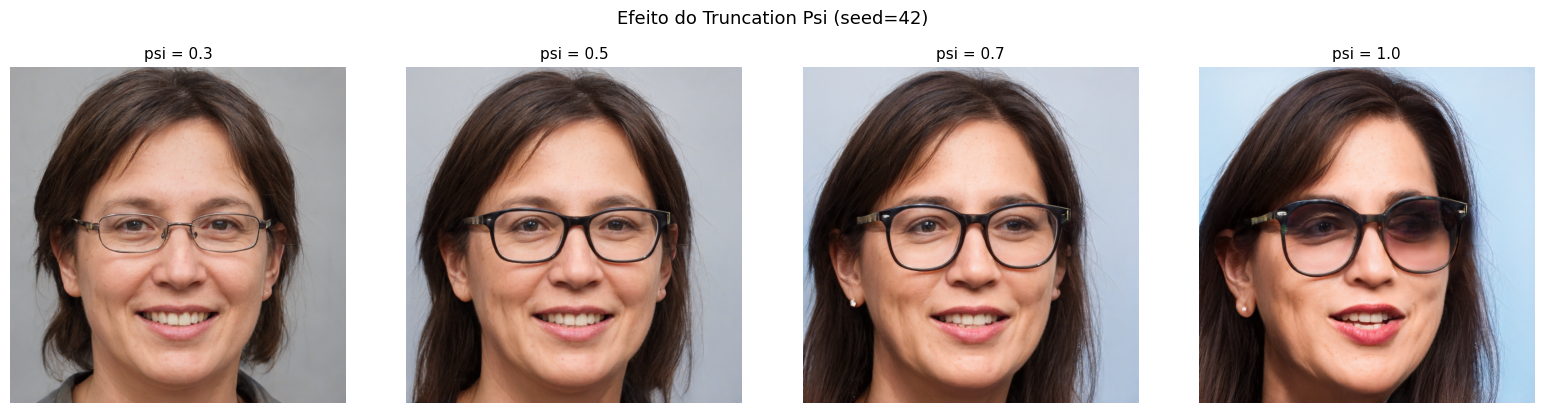

In [ ]:
SEED_FIXO = 42
PSI_VALORES = [0.3, 0.5, 0.7, 1.0]

z_fixo = torch.from_numpy(
    np.random.RandomState(SEED_FIXO).randn(1, G.z_dim).astype(np.float32)
).to(device)

fig, axes = plt.subplots(1, len(PSI_VALORES), figsize=(4 * len(PSI_VALORES), 4))

with torch.no_grad():
    for ax, psi in zip(axes, PSI_VALORES):
        img_tensor = G(z_fixo, label, truncation_psi=psi, noise_mode="const")
        img_np = (img_tensor.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255)
        img_pil = PIL.Image.fromarray(img_np[0].cpu().numpy().astype(np.uint8), "RGB")
        ax.imshow(img_pil)
        ax.set_title(f"psi = {psi}", fontsize=11)
        ax.axis("off")

plt.suptitle(f"Efeito do Truncation Psi (seed={SEED_FIXO})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

O código abaixo gera uma imagem com seed aleatório e a salva. Funcionalidade semelhante ao site [thispersondoesnotexist.com](https://www.thispersondoesnotexist.com).

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Seed sorteado: 1395
Imagem salva em: output_images/seed_aleatorio_1395.png



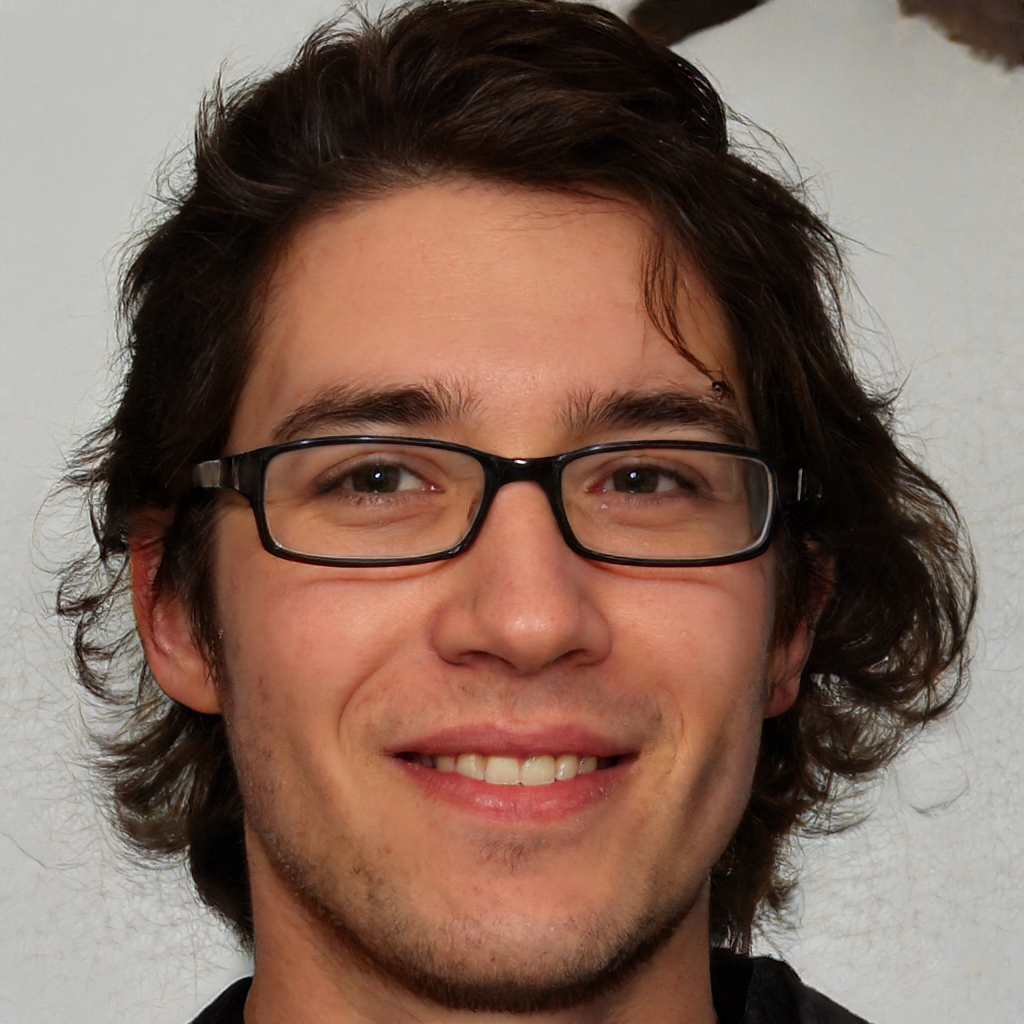


Imagem gerada com sucesso!


In [ ]:
import random

# 1. Gera um seed aleatório inteiro
seed_aleatorio = random.randint(0, 9999)

label = torch.zeros([1, G.c_dim], device=device)
imagens = []

with torch.no_grad():
    # 2. Usamos o seed aleatório gerado
    z = torch.from_numpy(
        np.random.RandomState(seed_aleatorio).randn(1, G.z_dim).astype(np.float32)
    ).to(device)

    img_tensor = G(z, label, truncation_psi=TRUNCATION_PSI, noise_mode="const")
    img_np = (img_tensor.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255)
    img_pil = PIL.Image.fromarray(img_np[0].cpu().numpy().astype(np.uint8), "RGB")

    # Salva a imagem
    caminho = os.path.join(OUTPUT_DIR, f"seed_aleatorio_{seed_aleatorio:04d}.png")
    img_pil.save(caminho)
    imagens.append((seed_aleatorio, img_pil))

    print(f"Seed sorteado: {seed_aleatorio}")
    print(f"Imagem salva em: {caminho}\n")

    # 3. MOSTRA A IMAGEM NO NOTEBOOK
    display(img_pil)

print(f"\nImagem gerada com sucesso!")